# Albero di decision
Si vuole progettare un classificatore che in fase di predizione, assegni le etichette facendo una serie di test.

Questi test sono organizzati a forma di albero, l'obiettivo e' in fase di fitting, generare l'albero migliore per predire le etichette.

Struttura dell'albero:
* `nodo`: e' un test del tipo `f(x) >= val`
* `archi`: mi portano al prossimo test
* `foglia`: le foglie corrispondono alle etichette assegnate.

## guadagno informativo
**Siano**:
* $D_p$: insieme di esempi releativi al nodo $p$
* $n = |D_p|$
* $n_c$: numero di esempi in $D_p$ appartenenti alla classe $c$

**probabilita di errore con due classi**:
$$
I_G(D_p) = \sum_{c} \frac{n_c}{n}\left( 1 - \frac{n_c}{n} \right) = 1-\sum_{c}\left(\frac{n_c}{n} \right)^2
$$
* tende 

**guadagno informativo**:
$$
IG(D_p) = I_G(D_p) - \left( \frac{|D_L|}{n} I_G(D_L) + \frac{n-|D_L|}{n} I_G(D_R) \right)
$$

**incertezza**:
$$
I_H(D_p) = - \sum_{c} \frac{n_c}{n}\log_2 \frac{n_c}{n}
$$

**impurita**: $I_G$ e $I_H$ sono misure di impurita.

**addestramento e foglie**: durante l'addestramento un nodo diventa foglia se gli esempi a questo associati appartengono tutti alla stessa classe.

**regioni rettangolari**: possiamo vedere i test come regioni di decisioni rettangolari

**iper parametri**: impurita, altezza massima dell'albeor, dimensione minima del dataset

## Implementazione

Un *nodo interno* è un dizionario con i seguenti campi:

- `'index'`: l'indice della colonna di `X` corrispondente alla caratteristica usata per il test;
- `'value'`: il valore con cui confrontare la caratteristica
- `'groups'`: una coppia che contiene $D_L$ e $D_R$
- `'left`, `'right'`: i riferimenti ai due figli

Un *nodo foglia* è semplicemente un valore, il nome della classe.

applicare `hstack` su $X,y$ vuol dire:
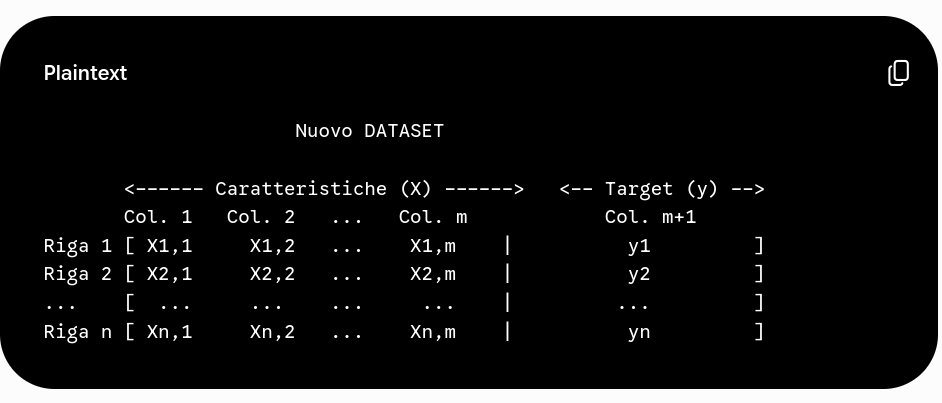


In [31]:
import os
import pandas as pd
import numpy as np
from graphviz import Digraph # per il disegno degli alberi

In [ ]:
class DecisionTree(object):
    def __init__(self, max_depth=3, min_size=1):
        self.max_depth = max_depth
        self.min_size = min_size
        self.tree = None
        self._impurity_fun = self._gini

    def fit(self, X, y):
        """ Costruisce l'albero di decisione """
        y = np.array(y).reshape(-1, 1)  # una colonna x tutte le righe che servono
        
        '''
        dataset contiene sia X che y impilati verticalmente, questa è 
        la soluzione più conveniente per semplificare le operazioni
        di filtro delle righe che porterà alle suddivisioni del dataset che
        definiranno i nodi dell'albero
        '''
        dataset =  np.hstack((X, y)) # Concatenazione orizzontale
        self.tree = self._build_tree(dataset, 1)

    def _build_tree(self, dataset, depth):
        """ Costruisce l'albero a partire dai dati """
        # il dataset e' hastack di X,y

        # fai il best split alla radice
        root = self._get_best_split(dataset)
        # ora fai lo split, in modo ricorsivo
        self._split(root, depth)
        return root
    
    def _get_best_split(self, dataset):
        """ Trova la feature (colonna di dataset) sulla quale esiste un valore  che  
        Massimizza il guadagno informativo su tutte le possibili suddivisioni ottenibili usando
        tutte le possibili caratteristiche.

        Quindi per ogni caratteristica index e per ogni esempio row, si divide il dataset
        in base al test x[index] < row[index] e se ne calcola  il guadagno informativo.
        Si sceglie indx e row[index] in modo da massimizzare questo valore 

        # O((n d)^2)
        """

        # best_score e' il guadagno informativo
        best_index, best_value, best_score, best_groups = None, None, float('-inf'), None
        # per ogni feature (tranne l'ultima)
        for index in range(dataset.shape[1] - 1):  # Escludiamo la colonna target
            # il valore per split assume un valore tra quelli nel dataset
            # per ogni riga nel dataset
            for row in dataset:
                # qui fai lo split usando il valore `row[index]`
                # ossia ritorna left,right dove left = data[:, index] < value
                groups = self._split_dataset(index, row[index], dataset)
                # calcola guadagno informativo
                ig = self._info_gain(dataset, groups)
                if ig > best_score:
                    best_index, best_value, best_score, best_groups = index, row[index], ig, groups

        # ritorna un nodo
        return {'index': best_index, 'value': best_value, 'groups': best_groups}
    
    def _info_gain(self, dataset, groups):
        """
        misura guadagno informativo sul dataset in base allo split in groups[0] e groups[1]
        """
        nl, nr = groups[0].shape[0], groups[1].shape[0]
        n = nl + nr
        # applica la formula, dove per ora _impurity_fun = self._gini
        ig = self._impurity_fun(dataset) - self._impurity_fun(groups[0])*nl/n - self._impurity_fun(groups[1])*nr/n
        return ig

    def _split_dataset(self, index, value, dataset):
        """ Divide il dataset in due gruppi in base al confronto della caratteristica
        index con value 
        
        costo: O(nd)
        """
        # dividi dataset in base a value

        # ritorna gli indici per cui ho < value, ottengo una maschera di indici
        mask = dataset[:, index] < value
        # usa la maskera per prendere left e right
        left, right = dataset[mask], dataset[~mask]

        return left, right

    def _split(self, node, depth):
        """ Cresce l'albero ricorsivamente """
        left, right = node['groups']
        #del node['groups']
        
        # Se uno dei gruppi è vuoto, assegniamo una foglia
        if left.size == 0 or right.size == 0:
            # crea una foglia prendendo l'etichetta che compare di piu nello stack di left e right
            node['left'] = node['right'] = self._create_leaf(np.vstack( (left, right) ))
            return

        # Fermiamo la crescita se abbiamo raggiunto la profondità massima
        if depth >= self.max_depth:
            node['left'], node['right'] = self._create_leaf(left), self._create_leaf(right)
            return

        # Se il gruppo sinistro è troppo piccolo, creiamo una foglia
        if len(left) <= self.min_size:
            node['left'] = self._create_leaf(left)
        else:
            node['left'] = self._get_best_split(left)
            # RICORSIONE: fai lo split a sinistra
            self._split(node['left'], depth + 1)

        # Se il gruppo destro è troppo piccolo, creiamo una foglia
        if len(right) <= self.min_size:
            node['right'] = self._create_leaf(right)
        else:
            node['right'] = self._get_best_split(right)
            # RICORSIONE: fai lo split a destra
            self._split(node['right'], depth + 1)

    def _create_leaf(self, group):
        """ Crea un nodo foglia con la classe più comune """

        # unique tra i due gruppi, trova i valori unici e salva il conteggio
        values, counts = np.unique(group[:,-1], return_counts=True)
        # trova il valore che massimizza il conteggio di np.unique
        return values[np.argmax(counts)]

    def _gini(self, dataset):
        # ricaviamo le etichette dall'ultima colonna
        labs, occur = np.unique(dataset[:,-1], return_counts=True)
        score = 0
        for i, _ in enumerate(labs):
            proportion = occur[i] / dataset.shape[0]
            score += proportion ** 2
        return 1-score

    def _predict_example(self, node, row):
        if row[node['index']] < node['value']:
            if self._is_leaf(node['left']):
                return node['left']
            else:
                return self._predict_example(node['left'], row)
                
        else:
            if self._is_leaf(node['right']):
                return node['right']
            else:
                return self._predict_example(node['right'], row)
            
    def _is_leaf(self, node):
        return not isinstance(node, dict)    
            
    def predict(self, row):
        """ Predice la classe di una singola riga """
        # innesca la ricerca a partire dalla radice dell'albero
        return self._predict_example(self.tree, row)

    def predict_batch(self, X):
        """ Predice su un intero dataset """
        return [self.predict(row) for row in X]
    
    def draw_tree(self):
        self.the_tree = Digraph()
    
        def add_nodes_edges(node, parent_id=None, edge_lab = 'SI'):
            if node is None:
                return
    
            # Se foglia (intero)
            if self._is_leaf(node):
                node_id = str(id(node))
                self.the_tree.node(node_id, str(node))
                if parent_id:
                    self.the_tree.edge(parent_id, node_id, edge_lab)
                return
    
            # Nodo interno
            node_id = str(id(node))
            label = f"f_{str(node.get('index',''))} < {str(node.get('value', ''))}" 
            self.the_tree.node(node_id, label)
    
            if parent_id:
                self.the_tree.edge(parent_id, node_id, edge_lab)
    
            add_nodes_edges(node.get('left'), node_id, 'SI')
            add_nodes_edges(node.get('right'), node_id, 'NO')
    
        add_nodes_edges(self.tree)

    def show_tree(self):
        return self.the_tree

## Complessità temporale
La complessità dell'addestramento coincide con quella richiesta dalla costruzione dell'albero. 

Le complessità di ogni metodo sono riportate nei commenti nella definizione della classe. I parametri `n` e `d` si riferiscono alla dimensione della/e matrice/i che ricevono in input.

Per completare il calcolo, occorre analizzare il costo della ricorsione, ovvero di tutte le chiamate del metodo `split_`. Procederemo per livelli. Il costo indotto dal livello 1, la radice, è $O(n\cdot d)$. Al livello 2, nel caso peggiore, le dimensioni dei dataset sono sbilanciate, uno dei due nodi contiene quasi tutti i campioni del dataset iniziale, quindi un costo $O(n\cdot d)$ anche in questo caso. La stessa cosa si ripete anche per i 4 nodi del livello successivo e così via fino alla profondità massima consentita $h$. Da questo segue che la complessità temporale, nel caso peggiore, risulta $O(h\cdot(n\cdot d)^2)$

La complessià della classificazione di un campione è data dal costo del metodo `predict_example_`. Questo esegue una serie di confronti di costo costante in un percorso radice foglia. Il costo temporale nel caso peggiore è $O(h)$.


## Esempi

In [33]:
import os
import numpy as np
import pandas as pd

s = os.path.join('dataset', '01-02-iris.csv')
df = pd.read_csv(s,
                 header=None,
                 encoding='utf-8')

In [34]:
from sklearn.model_selection import train_test_split

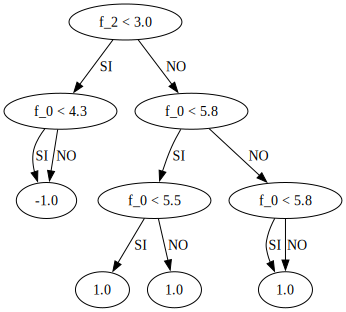

In [35]:
y = df.iloc[:100, 4].values
y = np.where(y == 'Iris-versicolor', 1, -1)

# extract sepal length and petal length
X = df.iloc[:100, [0, 1, 2, 3]].values

X_train, X_test, y_train, y_test = train_test_split(X, y)

tree = DecisionTree(max_depth=3, min_size=1)
tree.fit(X_train,y_train)
# print(f"Accuratezza: {np.mean([tree.predict_batch(X_test) == y_test])}")
tree.draw_tree()
tree.show_tree()

Accuratezza: 0.84


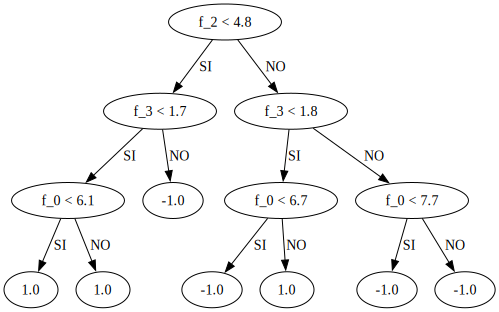

In [36]:
# [0:50] iris-setosa
# [50:100] iris-versicolor
# [100:150] iris-virginica
y = df.iloc[50:, 4].values
y = np.where(y == 'Iris-versicolor', 1, -1)

# extract sepal length and petal length
X = df.iloc[50:, [0, 1,2,3]].values

X_train, X_test, y_train, y_test = train_test_split(X, y)

tree = DecisionTree(max_depth=3, min_size=1)
tree.fit(X_train,y_train)
print(f"Accuratezza: {np.mean([tree.predict_batch(X_test) == y_test])}")
tree.draw_tree()
tree.show_tree()

# Esercizio
Analisi performance:
* `n_informative`: numero di feature informative, ossia quelle che dividono bene il dataset.
* `n_redundant`: sono ridondanti poiche generate come combinazione lineare di quelle informative. ossia sono dele copie.
* `n_repeated`: sono feature duplicate, spiccicate, paro paro.

In [37]:
import numpy as np
from scipy.spatial import KDTree
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# dunque di 10 feature, 7 sono informative
X,y = make_classification(n_samples=1000, n_features=10,
                        n_informative=4, n_classes=4, random_state=0)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

tree = DecisionTree(max_depth=50, min_size=10)
tree.fit(X_train,y_train)

print(f"Accuratezza train : {np.mean([tree.predict_batch(X_train) == y_train])}")
print(f"Accuratezza test  : {np.mean([tree.predict_batch(X_test) == y_test])}")

Accuratezza train : 0.9146666666666666
Accuratezza test  : 0.716


**attenzione**: c'ho un botto di overfitting. e ci mette tanto tempo, tipo 5s.

## foreste casuali: addestramento e iperparametri
* $k$ alberi decisionali, variegati. classifico prendendo l'etichetta piu frequente tra questi $k$.
* **iperparametri**: dimensione foresta, dimensione insiemi addestramento per ogni albero, numero di features usate.
* **varieta**: gli esempi usati per addestrare gli alberi devono essere abbastanza variegati tra loro in campioni e feature usate


## introdurre varieta negli alberi
su $k$ alberi nella forestra, ognuno deve essere addestrato su un sottoinsieme $n'$ di esempi, e su un sottoinsieme $d'$ di features.

**scegliere gli esempi**: estrazione casuale con reinserimento

**bootstrap**: $n' \equiv n$, estraggo con reinserimento.

**scegliere le features**: $d' = \sqrt{d}$

**perche?**
* piu di un terzo dei campioni non verra' usato in fase di addestramento
* ogni coppia di insiemi di campioni differisce di $2/3$ elementi.

## proprieta del bootstrap

Sia $I$ ottenuto con bootstrap, ossia $n'=n$, calcoliamone la dimensione attesa per grandi valori di $n$.

sia:
$$
x_i = \left\{
\begin{array}{lcl}
1 & & \text{se l'esempio $i$ è in $I$}\\
0 & & \text{altrimenti}
\end{array}
\right.
$$

$$
|I| = \sum_{i=1}^n x_i
$$

$$
E(|I|) = \sum_{i=1}^n E(x_i) = \sum_{i=1}^n P(x_i=1) 
$$

$$
P(x_i=1) = 1 - Pr(\text{$i$ non venga mai scelto}) =
1-\left( 1 - \frac{1}{n}\right)^n
$$

Al crescere di $n$, il secondo termine della differenza tende a $1/e$ da cui segue che:
$$
1-\left(1 - \frac{1}{n}\right)^n \to 1-\frac{1}{e}
$$
ed: 
$$
E(|I|) \rightarrow  n\left( 1-\frac{1}{e} \right) \approx 0.63 \cdot n.
$$

**Conclusione**: Quindi circa il $37\%$ degli esempi resta fuori (*out of bag*). Questi possono essere messi da parte ed utilizzati per testare il modello.

## $E(|I_0\cap I_1|)$: come prima ma faccio il quadrato del risultato
Con il prossimo conto cerchiamo di capire quanto hanno in comune due sottoinsieme $I_0$ e $I_1$ ottenuti con la tecnica del bootstrap.

Calcoliamo $E(|I_0\cap I_1|)$. Analogamente a quanto fatto prima definiamo

$$
x_i = \left\{
\begin{array}{lcl}
1 & & \text{se l'esempio $i$ è in $I_0\cap I_1$}\\
0 & & \text{altrimenti}
\end{array}
\right.
$$

quindi $E(|I_0 \cap I_1|) = \sum_{i=1}^n E(x_i)$. Questa volta

$$
Pr(x_i = 1) = 1 - Pr(x_i=0)
$$

$$
= Pr(\text{$i$ non viene mai estratto per $I_0$ e non viene mai estratto per $I_1$})
$$

$$
= \left( 1-\left( 1 - \frac{1}{n}\right)^n \right)^2
$$

$$
\rightarrow \left( 1-\frac{1}{e} \right)^2 \approx 0.4
$$

Quindi $E(|I_0 \cap I_1|) \approx 0.4\cdot n$. In altre parole, ogni coppia di alberi viene addestrata su insiemi che differiscono tra loro per circa il $66\%$ degli esempi. Questo, insieme alla scelta casuale delle feature contribuisce a creare alberi diversi tra di loro e questo favorisce il modello.

## Codice

### Classe `DecisionTree`
* `num_feats`: quante features uso per l'albero? in `__init__` scelgo le feature a caso tra l'insieme delle feature del dataset. `replace = False`: l'estrazione avviene senza reinserimento.
* `_get_best_split`: e' stato modificato utilizzato durante l'addestramento per aggiungere i nodi migliori all'albero, iterando ora sugli indici selezionati in `__init__` 

La modifica da apportare alla classe `DecisionTree` riguarda l'introduzione della possibilità di addestrare l'albero su un sottoinsieme delle caratteristiche piuttosto che su tutte. Tra i parametri è stato aggiunto `num_feats` che permette di speficicare quante features utilizzare. Queste verranno scelte a caso nel metodo `__init__`. La funzione utilizzata sarà `choice` di `numpy.random` con la quale verranno selezionati casualmente gli indici delle feature; il parametro `replace = False` indica che l'estrazione avviene senza reinserimento.

L'altro metodo modicicato è `_get_best_split`, utilizzato durante l'addestramento per aggiungere nel modo migliore i nodi all'albero. Nel ciclo principale, anziché iterare su tutti gli indici delle caratteristice, itera su quelli selezionati in `__init__`.

In [39]:
class DecisionTree(object):
    def __init__(self, max_depth=3, min_size=1,
                 num_feats = None, random_state = 0):      
        
        self.max_depth = max_depth
        self.min_size = min_size
        self.tree = None
        self._impurity_fun = self._gini
            
        self._num_feats = num_feats
        self._random_state = random_state
        
        # indici delle features usate, in caso = None, tutte le features
        self._feature_indxs = None
            
    def fit(self, X, y):
        """ Costruisce l'albero di decisione """
        y = np.array(y).reshape(-1, 1)  # anziché vettore, una matrice ad una colonna x tutte le righe che servono
        
        '''
        dataset contiene sia X che y impilati verticalmente, questa è 
        la soluzione più conveniente per semplificare le operazioni
        di filtro delle righe che porterà alle suddivisioni del dataset che
        definiranno i nodi dell'albero
        '''
        
        # scegli randomicamente le feature da usare
        if self._num_feats!= None and self._num_feats < X.shape[1]:
            rng = np.random.default_rng(seed=self._random_state)
            # indici delle features usate
            self._feature_indxs = rng.choice(np.arange(X.shape[1]), self._num_feats, replace=False)
        else:
            self._feature_indxs = np.arange(X.shape[1])
            
        
        dataset =  np.hstack((X, y)) # Concatenazione orizzontale
        self.tree = self._build_tree(dataset, 1)

    def _info_gain(self, dataset, groups):
        # UGUALE A PRIMA
        nl, nr = groups[0].shape[0], groups[1].shape[0]
        n = nl + nr
        ig = self._impurity_fun(dataset) - self._impurity_fun(groups[0])*nl/n - self._impurity_fun(groups[1])*nr/n
        return ig
    
    def _gini(self, dataset):
        labs, occur = np.unique(dataset[:,-1], return_counts=True)
        score = 0
        for i, _ in enumerate(labs):
            proportion = occur[i] / dataset.shape[0]
            score += proportion ** 2
        return 1-score

    def _split_dataset(self, index, value, dataset):
        """ Divide il dataset in due gruppi in base al confronto della caratteristica
        index con value"""
        mask = dataset[:, index] < value
        left, right = dataset[mask], dataset[~mask]

        return left, right

    def _get_best_split(self, dataset):
        """ Trova la feature (colonna di dataset) sulla quale esiste un valore tale che  
        Massimizza il guadagno informativo su tutte le possibili suddivisioni ottenibili usando
        tutte le possibili caratteristiche.

        Quindi per ogni caratteristica index e per ogni esempio row, si divide il dataset
        in base al test x[index] < row[index] e se ne calcola  il guadagno informativo.
        Si sceglie indx e row[index] in modo da massimizzare questo valore 
        """
        best_index, best_value, best_score, best_groups = None, None, float('-inf'), None
        for index in self._feature_indxs: 
            for x in dataset:
                groups = self._split_dataset(index, x[index], dataset)
                ig = self._info_gain(dataset, groups)
                if ig > best_score:
                    best_index, best_value, best_score, best_groups = index, x[index], ig, groups

        # ritorna un nudo
        return {'index': best_index, 'value': best_value, 'groups': best_groups}

    def _create_leaf(self, group):
        """ Crea un nodo foglia con la classe più comune """
        values, counts = np.unique(group[:,-1], return_counts=True)
        return values[np.argmax(counts)]

    def _split(self, node, depth):
        """ Cresce l'albero ricorsivamente """
        left, right = node['groups']
        #del node['groups']
        
        # Se uno dei gruppi ï¿½ vuoto, assegniamo una foglia
        if left.size == 0 or right.size == 0:
            node['left'] = node['right'] = self._create_leaf(np.vstack( (left, right) ))
            return

        # Fermiamo la crescita se abbiamo raggiunto la profonditï¿½ massima
        if depth >= self.max_depth:
            node['left'], node['right'] = self._create_leaf(left), self._create_leaf(right)
            return

        # Se il gruppo sinistro ï¿½ troppo piccolo, creiamo una foglia
        if len(left) <= self.min_size:
            node['left'] = self._create_leaf(left)
        else:
            node['left'] = self._get_best_split(left)
            self._split(node['left'], depth + 1)

        # Se il gruppo destro ï¿½ troppo piccolo, creiamo una foglia
        if len(right) <= self.min_size:
            node['right'] = self._create_leaf(right)
        else:
            node['right'] = self._get_best_split(right)
            self._split(node['right'], depth + 1)

    def _build_tree(self, dataset, depth):
        """ Costruisce l'albero a partire dai dati """
        root = self._get_best_split(dataset)
        self._split(root, depth)
        return root

    def _is_leaf(self, node):
        return not isinstance(node, dict)

    def _predict_example(self, node, x):
        """ Predice il valore di una singola riga """
        if x[node['index']] < node['value']:
            if self._is_leaf(node['left']):
                return node['left']
            else:
                return self._predict_example(node['left'], x)
                
        else:
            if self._is_leaf(node['right']):
                return node['right']
            else:
                return self._predict_example(node['right'], x)
            
    def predict(self, x):
        """ Predice la classe di una singola riga """
        return self._predict_example(self.tree, x)

    def predict_batch(self, X):
        """ Predice su un intero dataset """
        return [self.predict(x) for x in X]
    
    def draw_tree(self):
        self.the_tree = Digraph()
    
        def add_nodes_edges(node, parent_id=None, edge_lab = 'SI'):
            if node is None:
                return
    
            # Se foglia (intero)
            if self._is_leaf(node):
                node_id = str(id(node))
                self.the_tree.node(node_id, str(node))
                if parent_id:
                    self.the_tree.edge(parent_id, node_id, edge_lab)
                return
    
            # Nodo interno
            node_id = str(id(node))
            label = f"f_{str(node.get('index',''))} < {str(node.get('value', ''))}" 
            self.the_tree.node(node_id, label)
    
            if parent_id:
                self.the_tree.edge(parent_id, node_id, edge_lab)
    
            add_nodes_edges(node.get('left'), node_id, 'SI')
            add_nodes_edges(node.get('right'), node_id, 'NO')
    
        add_nodes_edges(self.tree)

    def show_tree(self):
        return self.the_tree

In [ ]:
class RandomForest(object):
    @staticmethod
    def mode( a ):
        '''
        parametro: a, un array-like

        return: l'elemento più frequente ed il numero di occorrenze

        '''
        itms, cnts = np.unique(np.array(a), return_counts=True )
        return itms[np.argmax(cnts)], max(cnts)

    def __init__(self, n_trees = 3, max_samples = None,
                 max_feat_func=np.sqrt, max_depth=3,
                 min_size=1,
                 random_state = 0):
        
        self._n_trees = n_trees
        self._max_samples = max_samples
        self._max_feat_func = max_feat_func
        
        self._random_state = random_state
        
        self.max_depth = max_depth
        self.min_size = min_size        

        self.trees = []
        self._used_rows = None # struttura usata per valutazione oob
        
        
    def fit(self, X, y):
        # Numero di caratteristiche calcolate come funzione del
        # numero di colonne di X

        # il numero di feature e' calcolato usando `_max_feat_func` che e' impostata a np.sqrt
        # X.shape[1] e' il numero di feature, X.shape[0] e' il numero di righe
        num_feats = int(self._max_feat_func(X.shape[1]))
        rng = np.random.default_rng(seed=self._random_state)

        # crea matrice booleana n*k con n=righe e k=numero di alberi
        self._used_rows = np.zeros( (X.shape[0], self._n_trees), dtype=bool)
        # used_rows[i,t] vale True se la riga i è stata usata per
        # addestrare l'albero t

        if self._max_samples == None:
            self._max_samples = X.shape[0]
             
        for i in range(self._n_trees):
            # ATTENZIONE: replace=True e poi unique. Perche' voglio intenzionalmente estrarre ripetutamente
            # lo stesso indice, piu volte. cosi c'e' (come visto prima) la probabilita di non estrarre altri indici.
            rnd_rows = np.unique(rng.choice(np.arange(X.shape[0]), self._max_samples, replace=True))
            self._used_rows[rnd_rows, i] = True # righe rnd_rows usate per albero i
            tree = DecisionTree(max_depth = self.max_depth, 
                                min_size = self.min_size,
                                num_feats = num_feats,
                                random_state = i
                               )

            # fai il fit con le righe selezionate
            Xf = X[rnd_rows, :]
            yf = y[rnd_rows]
    
            tree.fit(Xf, yf)
            self.trees.append(tree)
            
        # valutazione con i campioni non usati
        self._oob_valutation(X, y)
    
    def predict(self, x):
        predictions = np.empty(self._n_trees, dtype=object)
        
        for i in range(self._n_trees):
            predictions[i] = self.trees[i].predict(x)

        return RandomForest.mode(predictions)
        
    def _oob_valutation(self, X, y):
        '''
        ogni esempio verrà utilizzato per valutare le prestazioni degli alberi di cui era out-of-bag
        '''

        successes, n = 0, 0 # numero di successi e numero di esperimenti (esempi oob almeno una volta)
        
        for i in range(X.shape[0]):        
            xi, yi = X[i], y[i]

            predictions_xi = []
            
            for j in range(self._n_trees): 
                # fai la predizione se xi non e' stato usato per addestrare l'albero j
                if not self._used_rows[i][j]:
                    predictions_xi.append(self.trees[j].predict(xi))

            # prediction_xi = [] se la stessa xi e' stata usata per addestrare tutti gli alberi
            if predictions_xi != []:
                # fai la moda, ottieni l'etichetta piu ricorrente
                outcome, _ = RandomForest.mode(predictions_xi)
                # se ho predetto correttamente fai success += 1
                successes += 1 if outcome == yi else 0
                n += 1

        self._oob_accuracy = successes/n

    def get_accuracy(self):
        return self._oob_accuracy

    ## esercizio
            

In [ ]:
# dunque di 10 feature, 7 sono informative
X,y = make_classification(n_samples=1000, n_features=10,
                        n_informative=4, n_classes=4, random_state=0)

In [41]:
rf = RandomForest(max_feat_func=lambda d: d**0.5, max_depth=10, n_trees = 20, min_size=10)
rf.fit(X_train,y_train)

preds = np.array([rf.predict(x)[0] for x in X]) == y

print('Accuratezza su insieme di addestramento', preds.sum()/preds.shape[0])
print('Accuratezza su esempi out-of-bag', rf.get_accuracy())

preds = np.array([rf.predict(x)[0] for x in X_test]) == y_test

print('Accuratezza su insieme di test', preds.sum()/preds.shape[0])

Accuratezza su insieme di addestramento 0.844
Accuratezza su esempi out-of-bag 0.5013333333333333
Accuratezza su insieme di test 0.608


## Esercizio: da fare!!!@#!#@$

In un problema di classificazione in cui il numero di caratteristiche e di campioni è molto elevato, può essere utile ridurre il numero di feature utilizzate, al fine di migliorare l'efficienza degli algoritmi. L’obiettivo è mantenere solo le caratteristiche più *informative*, eliminando quelle meno rilevanti.

Durante la costruzione di un albero decisionale, a ogni iterazione viene selezionata la feature che massimizza il guadagno informativo, ovvero quella che contribuisce maggiormente a ridurre l'impurità (ad esempio, usando entropia o indice di Gini). Questa quantità può essere sfruttata per misurare l'importanza di ciascuna feature.

L’importanza di una feature può essere definita come la somma dei guadagni informativi generati ogni volta che tale feature è utilizzata in uno split, aggregando tali contributi: su tutti i nodi in cui la feature compare, e su tutti gli alberi della foresta. Infine, i valori vengono normalizzati in modo che la somma di tutte le importanze sia pari a 1.

Per implementare questa funzionalità, si propone di modificare la classe `RandomForest` (ed eventualmente le classi collegate) aggiungendo un metodo `feature_importance(self)` che dovrà restituire un dizionario che associ l'indice di ogni caratteristica con la sua importanza normalizzata.